In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np
import seaborn as sb

In [2]:
df = pd.read_csv(
    r"C:\Users\admin\Downloads\website_Data_set\data_export_website_modified.csv"
)

In [3]:
df.columns= df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns={"channel group","DateHour","Users","sessions","Enggaged session","Average Engagment time per session","Engagement sessions per user",	"Event per session","Engagement  Rate","Event count","Bouns Rate"	}


In [4]:
df

,channel group,Enggaged session,Engagement sessions per user,Engagement Rate,Average Engagment time per session,Event per session,Bouns Rate,Event count,DateHour,sessions,Users
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402,77.04
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147,63.92
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069,55.92
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044,29.36
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001,29.36
...,...,...,...,...,...,...,...,...,...,...,...
3187,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,42.47
3188,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,42.47
3189,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,42.47
3190,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,42.47


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   channel group                       3192 non-null   str    
 1   Enggaged session                    3192 non-null   str    
 2   Engagement sessions per user        3192 non-null   str    
 3   Engagement  Rate                    3192 non-null   str    
 4   Average Engagment time per session  3192 non-null   str    
 5   Event per session                   3192 non-null   str    
 6   Bouns Rate                          3192 non-null   str    
 7   Event count                         3192 non-null   str    
 8   DateHour                            3192 non-null   str    
 9   sessions                            3192 non-null   str    
 10  Users                               3192 non-null   float64
dtypes: float64(1), str(10)
memory usage: 274.4 KB


In [6]:
df["DateHour"]=pd.to_datetime(df["DateHour"],format="%Y%m%d%H",errors='coerce')

In [7]:
numeric_cols=df.columns.drop(["channel group","DateHour"])
df[numeric_cols]=df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df["hours"]=df["DateHour"].dt.hour

In [14]:
df["sessions"] = pd.to_numeric(df["sessions"], errors="coerce")
df["Users"] = pd.to_numeric(df["Users"], errors="coerce")

#Total users by channel

C:\Users\admin\AppData\Local\Temp\ipykernel_11148\1381526155.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


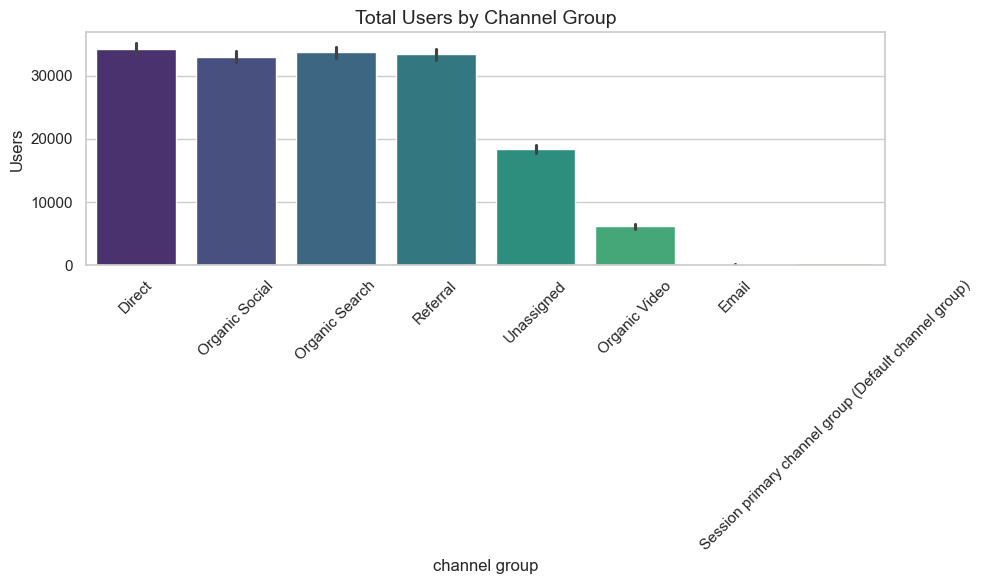

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Column names clean karna
df.columns = df.columns.str.strip()

# Plot style
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="channel group",
    y="Users",
    estimator=sum,
    palette="viridis"
)

plt.title("Total Users by Channel Group", fontsize=14)
plt.xlabel("channel group")
plt.ylabel("Users")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
#Average engagement time by channel

C:\Users\admin\AppData\Local\Temp\ipykernel_11148\3440236647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=df,x="channel group",y="Average Engagment time per session",estimator=np.mean, palette="magma")


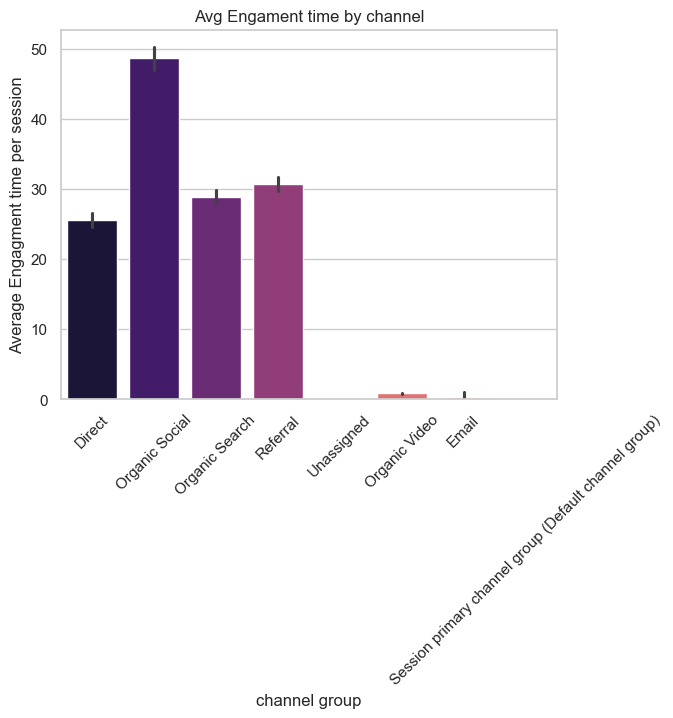

In [26]:
plt.Figure(figsize=(8,5))
sb.barplot(data=df,x="channel group",y="Average Engagment time per session",estimator=np.mean, palette="magma")
plt.title("Avg Engament time by channel")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Engagement Rate Distribution by channel

C:\Users\admin\AppData\Local\Temp\ipykernel_11148\942673413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(data=df,x="channel group",y="Engagement  Rate",palette="coolwarm")


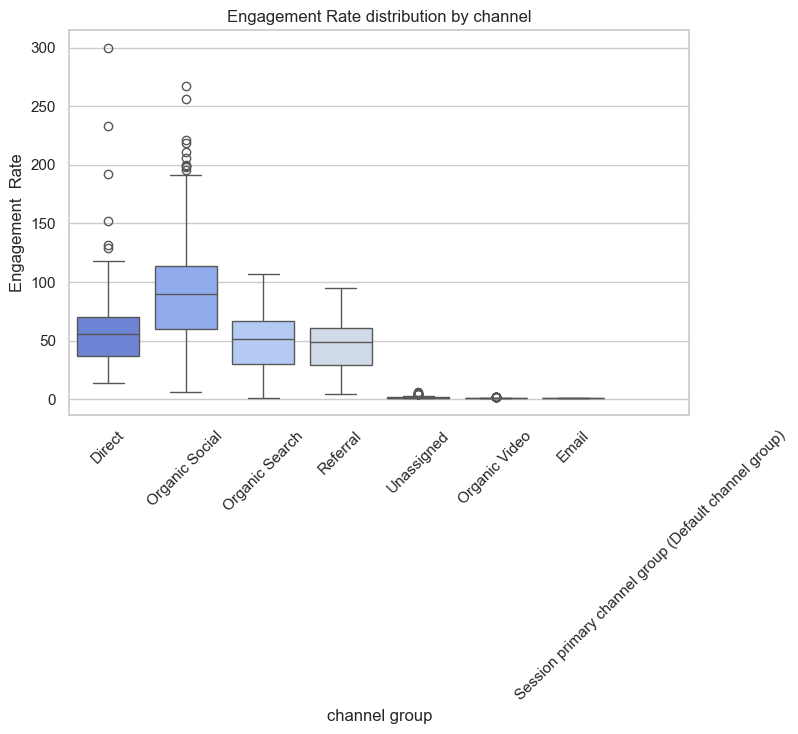

In [30]:
plt.figure(figsize=(8,5))
sb.boxplot(data=df,x="channel group",y="Engagement  Rate",palette="coolwarm")
plt.title("Engagement Rate distribution by channel")
plt.xticks(rotation=45)
plt.show()

#Engaged vs non Engaged sessions

In [33]:
session_df=df.groupby("channel group")[["sessions","Enggaged session"]].sum().reset_index()
session_df["Non-Enggaged session"]=session_df["Session"]-session_df["Enggaged session "]
session_df_melted=session_df.melt(id_vars="channel group",value_vars=["Enggaed ","Non-Enggaged session"])

plt.figure(figsize=(8,5))
sb.barplot(date=session_df_melted,x="channel group",y="value",hue="variable")
plt.title("Enggaged session vs Non-Enggaged session Session")
plt.xticks(rotation=45)
plt.show()

KeyError: 'Session'

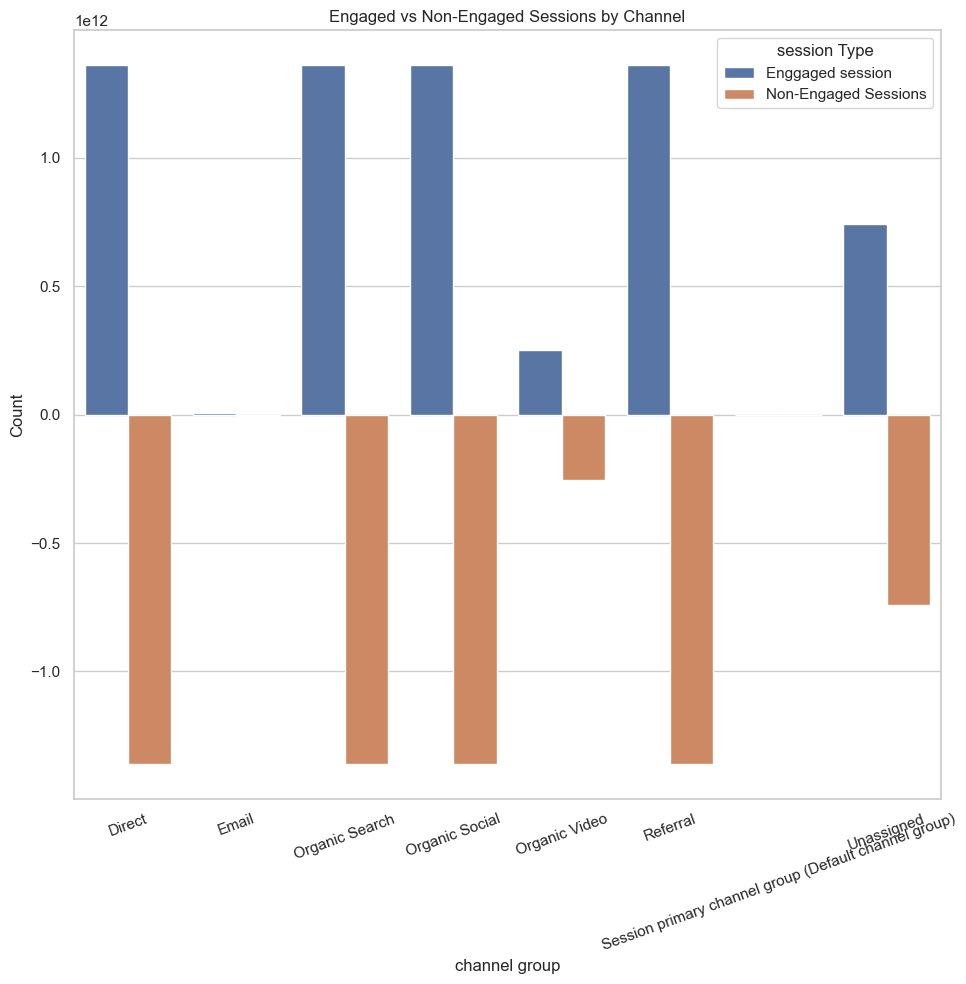

In [45]:

session_df = df.groupby("channel group")[["sessions", "Enggaged session"]].sum().reset_index()

# Create Non-Engaged Sessions
session_df["Non-Engaged Sessions"] = (
    session_df["sessions"] - session_df["Enggaged session"]
)

# Convert wide to long format
session_df_melted = session_df.melt(
    id_vars="channel group",
    value_vars=["Enggaged session", "Non-Engaged Sessions"],
    var_name="session Type",
    value_name="Count"
)

# Plot
plt.figure(figsize=(10,10))

sb.barplot(
    data=session_df_melted,   # data, not date
    x="channel group",
    y="Count",
    hue="session Type"
)

plt.title("Engaged vs Non-Engaged Sessions by Channel")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype        
---  ------                              --------------  -----        
 0   channel group                       3192 non-null   str          
 1   Enggaged session                    3182 non-null   float64      
 2   Engagement sessions per user        3182 non-null   float64      
 3   Engagement  Rate                    3182 non-null   float64      
 4   Average Engagment time per session  3182 non-null   float64      
 5   Event per session                   3182 non-null   float64      
 6   Bouns Rate                          3182 non-null   float64      
 7   Event count                         3182 non-null   float64      
 8   DateHour                            0 non-null      datetime64[s]
 9   sessions                            3182 non-null   float64      
 10  Users                               3192 non-nu

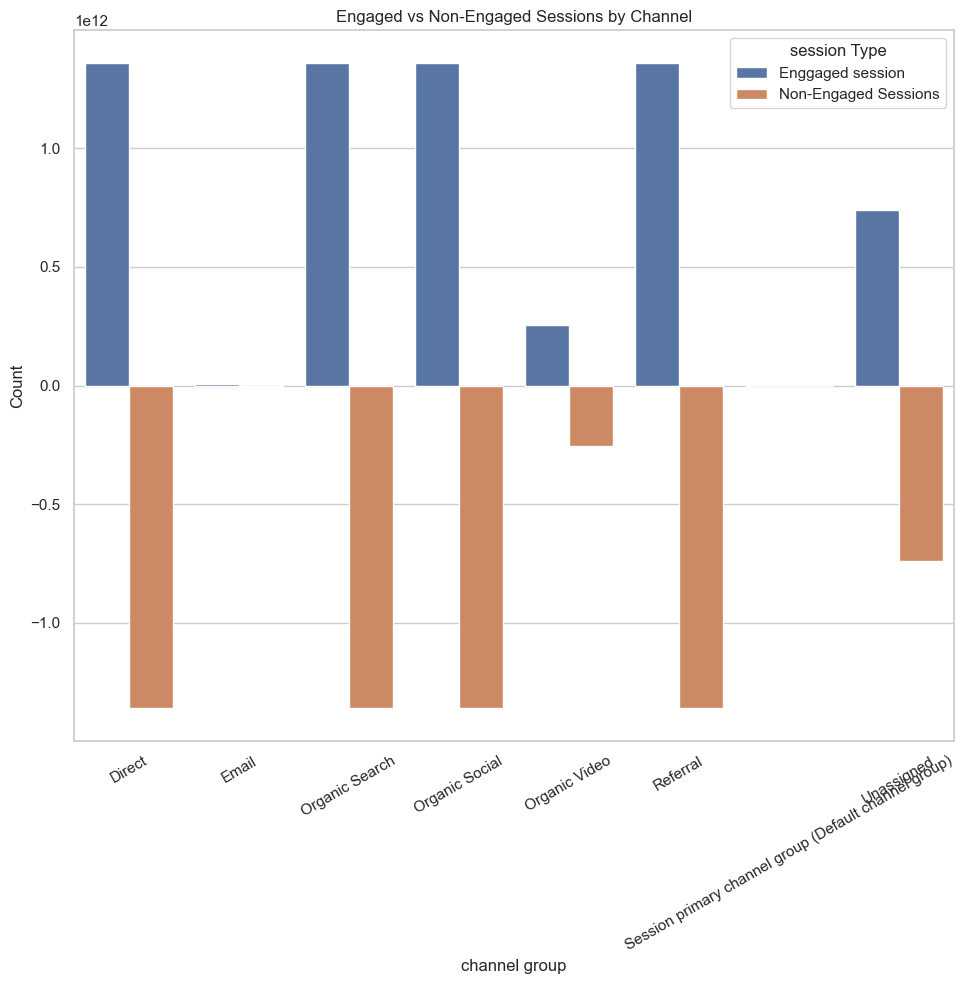

In [51]:
session_df = (
    df.groupby("channel group")[["sessions", "Enggaged session"]]
      .sum()
      .reset_index()
)

session_df["Non-Engaged Sessions"] = (
    session_df["sessions"] - session_df["Enggaged session"]
)

session_df_melted = session_df.melt(
    id_vars="channel group",
    value_vars=["Enggaged session", "Non-Engaged Sessions"],
    var_name="session Type",
    value_name="Count"
)

plt.figure(figsize=(10,10))

sb.barplot(
    data=session_df_melted,
    x="channel group",
    y="Count",
    hue="session Type"
)

plt.title("Engaged vs Non-Engaged Sessions by Channel")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype        
---  ------                              --------------  -----        
 0   channel group                       3192 non-null   str          
 1   Enggaged session                    3182 non-null   float64      
 2   Engagement sessions per user        3182 non-null   float64      
 3   Engagement  Rate                    3182 non-null   float64      
 4   Average Engagment time per session  3182 non-null   float64      
 5   Event per session                   3182 non-null   float64      
 6   Bouns Rate                          3182 non-null   float64      
 7   Event count                         3182 non-null   float64      
 8   DateHour                            0 non-null      datetime64[s]
 9   sessions                            3182 non-null   float64      
 10  Users                               3192 non-nu

Analysis website Traffic

In [82]:
print("Total sessions:", df["sessions"].sum())
print("Total Users:", df["Users"].sum())
print("Average Bounce Rate:", round(df["Bouns Rate"].mean(), 2), "%")

Total sessions: 770911.0
Total Users: 159310.25
Average Bounce Rate: 0.61 %


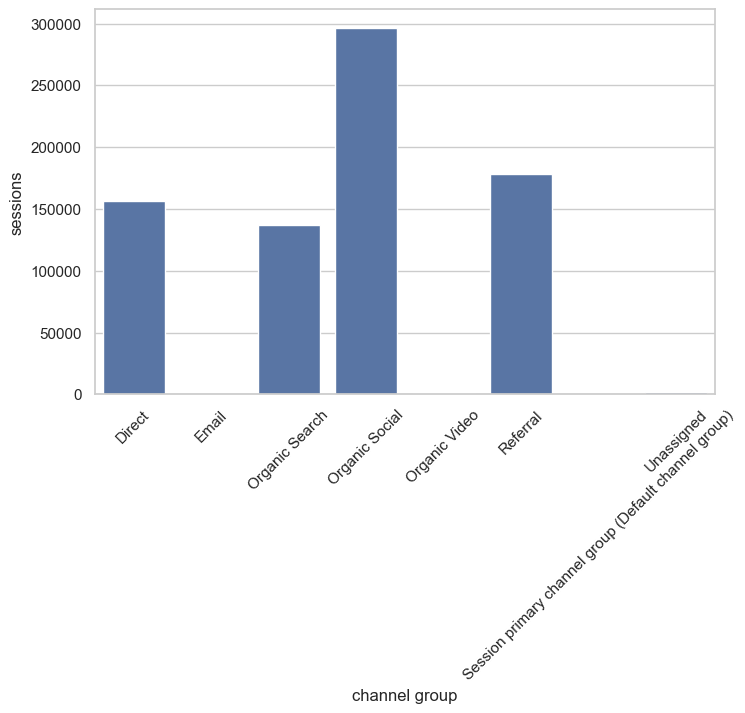

In [86]:
channel = df.groupby("channel group")[["sessions","Users"]].sum().reset_index()

import seaborn as sns

plt.figure(figsize=(8,5))
sns.barplot(data=channel, x="channel group", y="sessions")
plt.xticks(rotation=45)
plt.show()

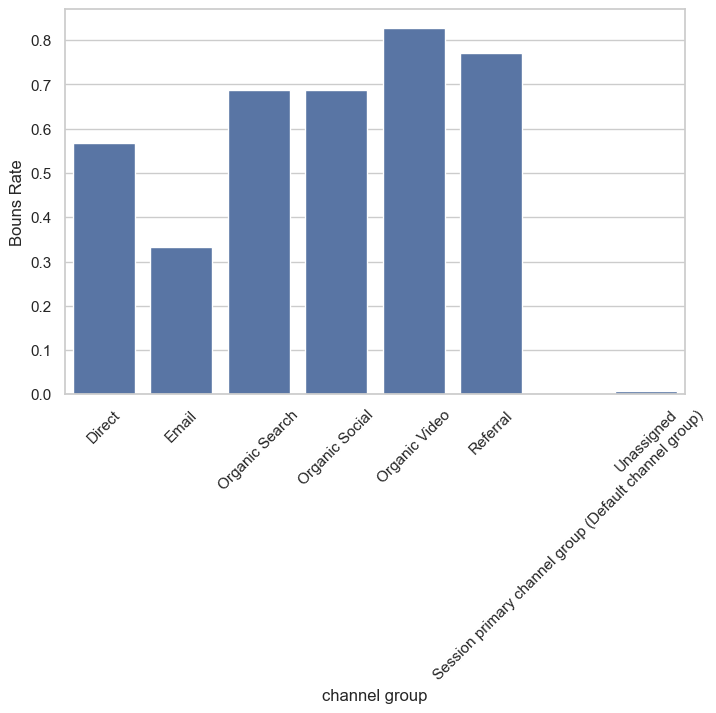

In [87]:
bounce = df.groupby("channel group")["Bouns Rate"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=bounce, x="channel group", y="Bouns Rate")
plt.xticks(rotation=45)
plt.show()

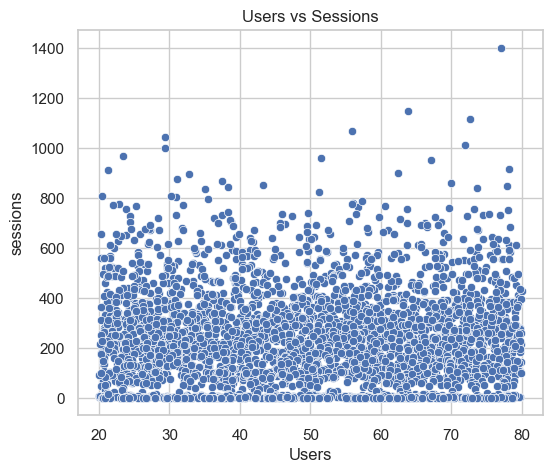

In [88]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="Users", y="sessions")
plt.title("Users vs Sessions")
plt.show()

In [90]:
top3 = (
    df.groupby("channel group")["sessions"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
)

print(top3)

channel group
Organic Social    296631.0
Referral          177992.0
Direct            156318.0
Name: sessions, dtype: float64


In [100]:

df.to_csv("output1.csv", index=False)